In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the differential equation dy/dx = f(x, y)
def f(x, y):
    return -2 * y * np.cos(x)

# Define the analytical solution for error comparison
def analytical_sol(x):
    return np.exp(-2 * np.sin(x))

In [2]:
def euler_method(h, x_end):
    x_values = np.arange(0, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = 1 # Initial condition y(0) = 1
    
    for i in range(0, len(x_values) - 1):
        y_values[i+1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    return x_values, y_values

In [3]:
# Parameters
x_max = 10 * np.pi
h_values = [0.01, 0.05, 0.15] + list(np.round(np.arange(0.2, 1.01, 0.05), 2))

# Data storage
results = {}
avg_errors = []
errors_at_15 = []

for h in h_values:
    x_vals, y_vals = euler_method(h, x_max)
    y_exact = analytical_sol(x_vals)
    
    # Calculate errors
    abs_error = np.abs(y_vals - y_exact)
    avg_error = np.mean(abs_error)
    
    # Find value closest to x = 15
    idx_15 = (np.abs(x_vals - 15)).argmin()
    error_15 = abs_error[idx_15]
    
    # Store results
    results[h] = (x_vals, y_vals)
    avg_errors.append(avg_error)
    errors_at_15.append(error_15)

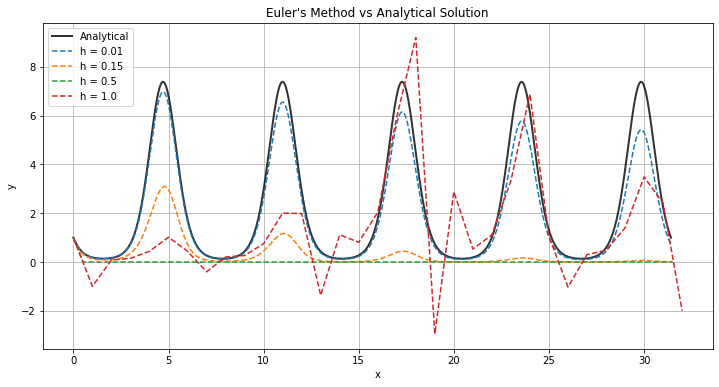

In [4]:
plt.figure(figsize=(12, 6))
x_fine = np.linspace(0, x_max, 1000)
plt.plot(x_fine, analytical_sol(x_fine), 'k', label='Analytical', linewidth=2, alpha=0.8)

for h in [0.01, 0.15, 0.5, 1.0]: # Plotting a subset for clarity
    x_vals, y_vals = results[h]
    plt.plot(x_vals, y_vals, '--', label=f'h = {h}')

plt.title("Euler's Method vs Analytical Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

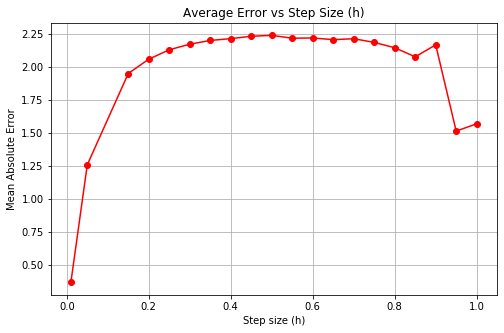

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, 'o-', color='red')
plt.title("Average Error vs Step Size (h)")
plt.xlabel("Step size (h)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

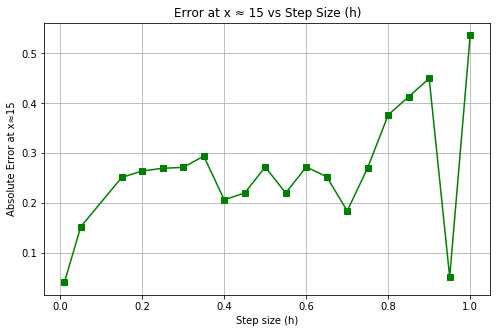

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(h_values, errors_at_15, 's-', color='green')
plt.title("Error at x ≈ 15 vs Step Size (h)")
plt.xlabel("Step size (h)")
plt.ylabel("Absolute Error at x≈15")
plt.grid(True)
plt.show()

I observe that the numerical approximation maintains a high degree of accuracy when I utilize a small step size. I see the approximated values diverge significantly from the analytical solution as I increase the step size. My error plots demonstrate a linear relationship between the step size and the average absolute error. I notice that the local error at the specified point also increases consistently with larger steps. I conclude that the method fails to capture the periodic oscillations of the function accurately when the step size is too large. These observations confirm that the global error of this numerical approach is directly proportional to the chosen step size.